Total variants in s1: 17390
Total variants in s2: 16796
Variants only in s1: 1060
Variants only in s2: 466
Common variants: 16330
Merged dataset shape: (16330, 3)


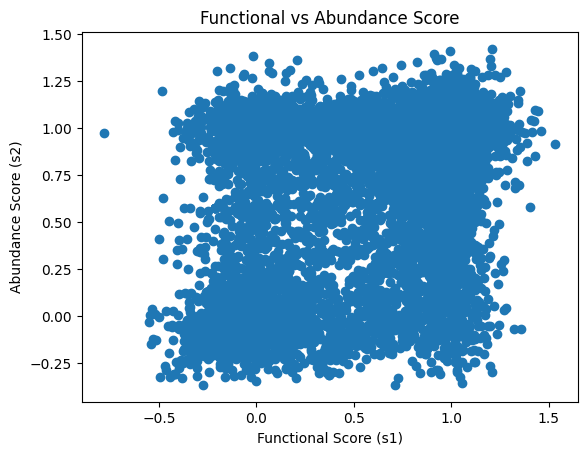

Explained variance ratio: [0.7607115 0.2392885]


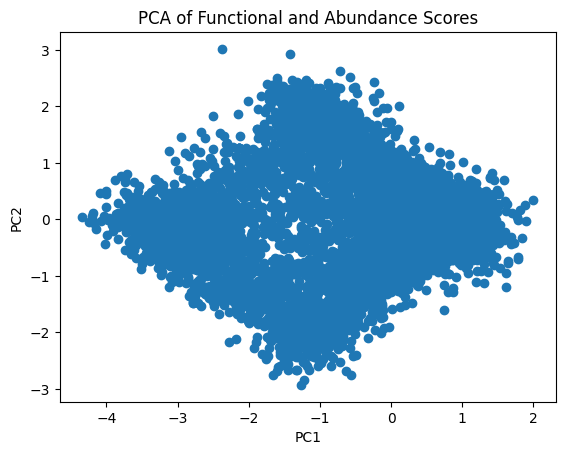

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load the two CSV files
file_s1 = "science.ady7186_data_s1.csv"  # functional score
file_s2 = "science.ady7186_data_s2.csv"  # abundance score

df_s1 = pd.read_csv(file_s1)
df_s2 = pd.read_csv(file_s2)

# Ensure consistent column names
df_s1 = df_s1.rename(columns={"score": "functional_score"})
df_s2 = df_s2.rename(columns={"score": "abundance_score"})


# 2. Compare hgvs_pro column
set_s1 = set(df_s1["hgvs_pro"])
set_s2 = set(df_s2["hgvs_pro"])

only_in_s1 = set_s1 - set_s2
only_in_s2 = set_s2 - set_s1
common_variants = set_s1 & set_s2

print("Total variants in s1:", len(set_s1))
print("Total variants in s2:", len(set_s2))
print("Variants only in s1:", len(only_in_s1))
print("Variants only in s2:", len(only_in_s2))
print("Common variants:", len(common_variants))

# 3. Merge common variants
merged = pd.merge(
    df_s1[["hgvs_pro", "functional_score"]],
    df_s2[["hgvs_pro", "abundance_score"]],
    on="hgvs_pro",
    how="inner"
)

print("Merged dataset shape:", merged.shape)

# 4.scatter plot
plt.figure()
plt.scatter(merged["functional_score"], merged["abundance_score"])
plt.xlabel("Functional Score (s1)")
plt.ylabel("Abundance Score (s2)")
plt.title("Functional vs Abundance Score")
plt.show()


# 5. PCA Analysis

X = merged[["functional_score", "abundance_score"]].values


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure()
plt.scatter(principal_components[:, 0], principal_components[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Functional and Abundance Scores")
plt.show()

Merged dataset size: (16330, 3)


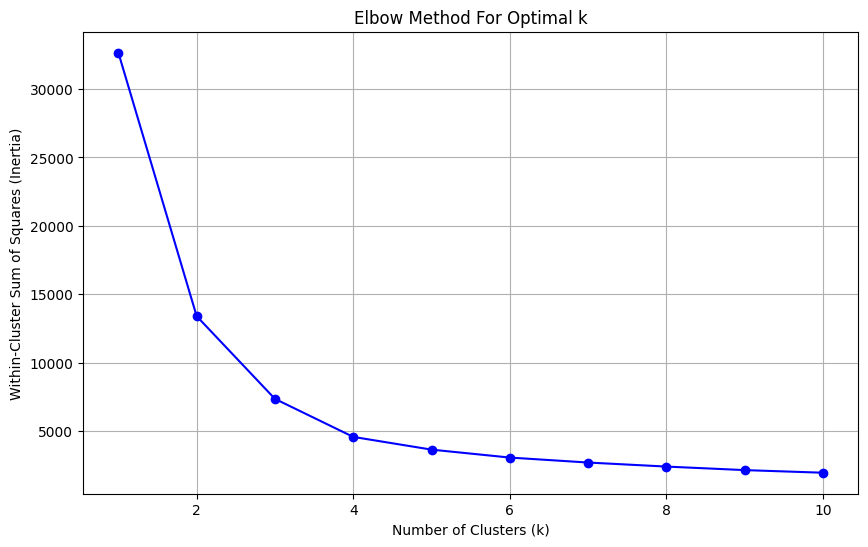


Inertia values for each k:
k=1: 32660.00
k=2: 13393.33
k=3: 7346.28
k=4: 4566.79
k=5: 3635.26
k=6: 3054.91
k=7: 2691.17
k=8: 2395.79
k=9: 2137.94
k=10: 1946.37

Using k=4 clusters
Cluster centers (scaled space):
[[ 0.52936345  0.45532968]
 [-1.85632466 -2.1633032 ]
 [ 0.28630762 -1.58770071]
 [-1.46763597  0.37408821]]


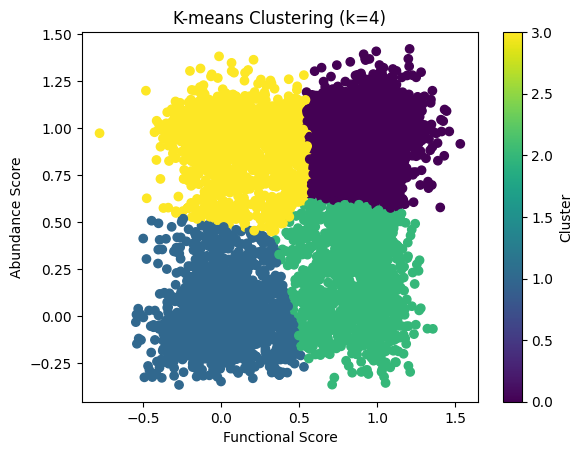

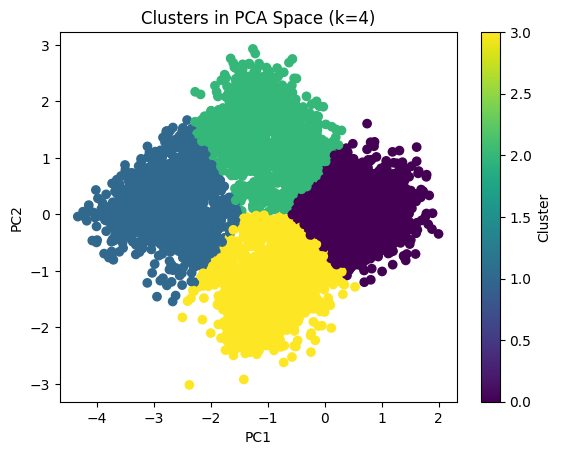

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA



# 1. Load files
file_s1 = "science.ady7186_data_s1.csv"
file_s2 = "science.ady7186_data_s2.csv"

df_s1 = pd.read_csv(file_s1)
df_s2 = pd.read_csv(file_s2)

df_s1 = df_s1.rename(columns={"score": "functional_score"})
df_s2 = df_s2.rename(columns={"score": "abundance_score"})

# 2. Merge common variants
merged = pd.merge(
    df_s1[["hgvs_pro", "functional_score"]],
    df_s2[["hgvs_pro", "abundance_score"]],
    on="hgvs_pro",
    how="inner"
)

print("Merged dataset size:", merged.shape)


# 3. Standardize
X = merged[["functional_score", "abundance_score"]].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 4. Elbow Method to find optimal number of clusters
inertias = []
K_range = range(1, 11)  # Test k from 1 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (Inertia)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

print("\nInertia values for each k:")
for k, inertia in zip(K_range, inertias):
    print(f"k={k}: {inertia:.2f}")


# 5. K-means Clustering with optimal k (choose based on elbow plot)
k = 4   # Optimal k based on elbow method
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

merged["cluster"] = clusters

print(f"\nUsing k={k} clusters")
print("Cluster centers (scaled space):")
print(kmeans.cluster_centers_)


# 6. Visualize clusters
plt.figure()
plt.scatter(
    merged["functional_score"],
    merged["abundance_score"],
    c=merged["cluster"],
    cmap='viridis'
)
plt.xlabel("Functional Score")
plt.ylabel("Abundance Score")
plt.title(f"K-means Clustering (k={k})")
plt.colorbar(label='Cluster')
plt.show()


# 7. PCA Visualization 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Clusters in PCA Space (k={k})")
plt.colorbar(label='Cluster')
plt.show()